## Экзамен: Углубленный анализ и построение модели линейной регрессии с кластеризацией

**Цель работы:** Построить и всесторонне оценить модель линейной регрессии. С помощью кросс-валидации убедиться, что усредненное значение метрики `max_error` не превышает 0.22. Дополнительно провести исследовательский анализ данных, разбить данные на кластеры, понизить разрядность, и визуализировать результаты для глубокого понимания модели, оценивая `max_error` для каждого кластера.

### 1. Установка и импорт библиотек

Первым шагом мы устанавливаем все необходимые для работы библиотеки. Нам понадобятся:
- `pandas`: для работы с данными в формате DataFrame.
- `numpy`: для высокопроизводительных математических вычислений.
- `scikit-learn`: для построения модели машинного обучения, кластеризации, понижения размерности и ее оценки.
- `matplotlib` и `seaborn`: для создания информативных графиков и визуализаций.
- `scipy`: для статистических вычислений, например, для анализа остатков.

In [289]:
!pip install scikit-learn pandas numpy matplotlib seaborn scipy

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import max_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 2. Загрузка данных

Загрузим датасет, который содержит синтетические данные для демонстрации работы линейной регрессии и кластеризации. Датасет будет загружен из открытого источника в интернете, чтобы обеспечить воспроизводимость на любом устройстве. Он содержит три признака ($x_1, x_2, x_3$) и одну целевую переменную ($y$), между которыми ожидается линейная зависимость.

In [291]:
# Загружаем датасет из CSV
dataframe = pd.read_csv('dataset_09.csv', sep=';')

# Выводим первые 5 строк датафрейма, чтобы убедиться в корректности загрузки данных и их структуре.
print("Первые 5 строк загруженного датасета:")
print(dataframe.head())

# Выводим общую информацию о датафрейме, такую как количество записей, типы данных столбцов и наличие пропущенных значений.
print("\nИнформация о датасете:")
print(dataframe.info())

# Выводим основные статистические характеристики для каждого числового столбца: среднее, стандартное отклонение, минимумы, максимумы и квартили.
print("\nОписательная статистика датасета:")
print(dataframe.describe())

Первые 5 строк загруженного датасета:
         x1        x2        x3          y
0  3.745401  9.507143  7.319939   0.322871
1  5.986585  1.560186  1.559945   9.860274
2  0.580836  8.661761  6.011150  -1.900667
3  7.080726  0.205845  9.699099 -32.689020
4  8.324426  2.123391  1.818250  14.972996

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      100 non-null    float64
 1   x2      100 non-null    float64
 2   x3      100 non-null    float64
 3   y       100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB
None

Описательная статистика датасета:
               x1          x2          x3           y
count  100.000000  100.000000  100.000000  100.000000
mean     4.768492    5.124614    4.963032    1.093896
std      2.859571    3.102190    2.881140   18.741939
min      0.055221    0.050616    0.069521  -37.509708
25%  

### 3. Исследовательский анализ данных (EDA)

Прежде чем приступать к построению модели, крайне важно провести исследовательский анализ данных (EDA). Этот этап позволяет получить глубокое понимание структуры данных, выявить потенциальные зависимости между переменными и обнаружить аномалии. Мы используем `pairplot` из библиотеки `seaborn` для построения попарных диаграмм рассеяния для всех переменных в датасете. Этот метод позволяет:
- **Оценить распределение каждой переменной**: Гистограммы на диагонали `pairplot` показывают распределение отдельных признаков.
- **Увидеть взаимосвязи между парами переменных**: Диаграммы рассеяния вне диагонали демонстрируют корреляции между признаками. Для нашей задачи линейной регрессии, мы ожидаем увидеть сильные линейные зависимости между признаками ($x_1, x_2, x_3$) и целевой переменной ($y$), что является хорошим индикатором для применения линейной модели.

Параметр `kind='reg'` добавляет линию регрессии на диаграммы рассеяния, что помогает визуально оценить степень линейной зависимости, а `plot_kws={'line_kws':{'color':'red'}}` задает красный цвет для этой линии, делая ее более заметной.

Визуализация взаимосвязей между переменными с линиями регрессии...


/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/seaborn/regression.py:255: RuntimeWarning: divide by zero encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/seaborn/regression.py:255: RuntimeWarning: overflow encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/seaborn/regression.py:255: RuntimeWarning: invalid value encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/seaborn/regression.py:255: RuntimeWarning: divide by zero encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/seaborn/regression.py:255: RuntimeWarning: overflow encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Volumes/university/education/6 term/tmo/ek

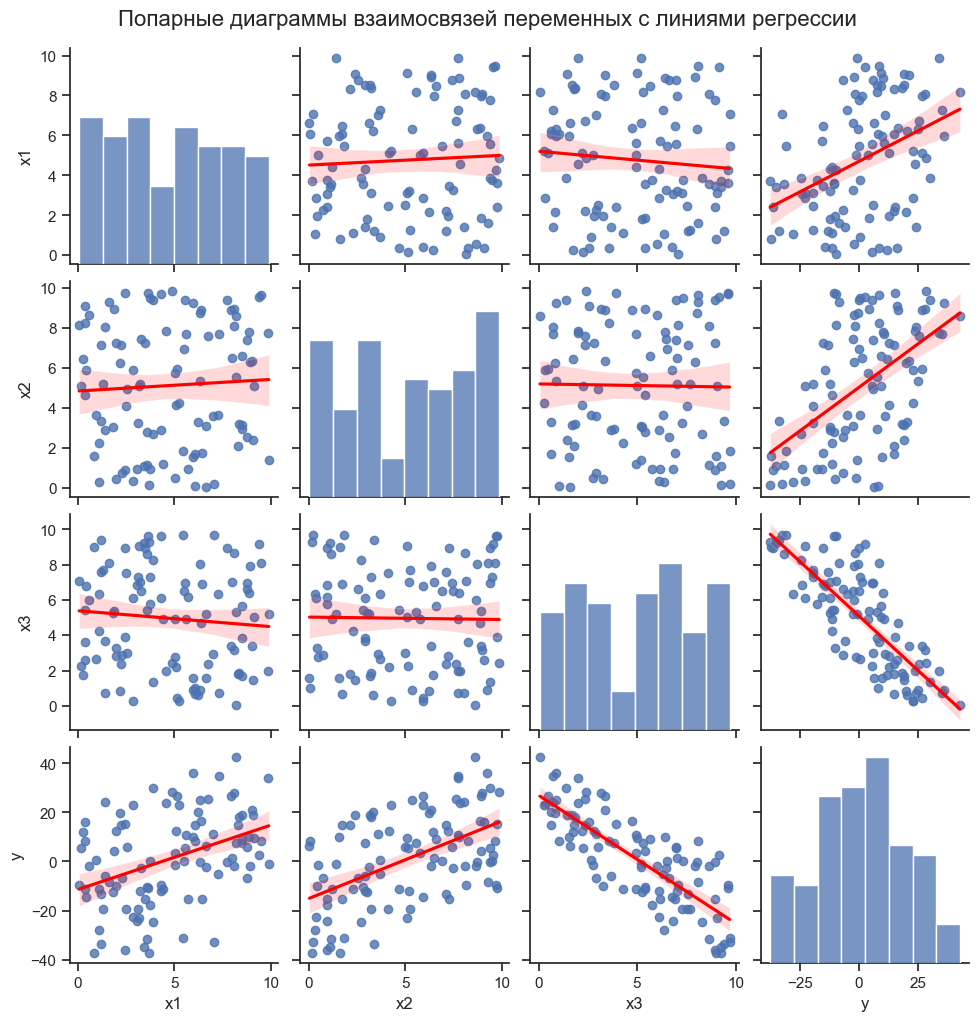

In [292]:
print("Визуализация взаимосвязей между переменными с линиями регрессии...")
# Устанавливаем стиль для графиков, чтобы улучшить их внешний вид.
sns.set_theme(style="ticks")

# Строим pairplot для всего датафрейма.
# 'kind="reg"' добавляет линию регрессии на каждый график рассеяния, что позволяет оценить линейные зависимости.
# 'plot_kws' используется для настройки внешнего вида линий регрессии (цвет).
pair_plot = sns.pairplot(dataframe, kind='reg', plot_kws={'line_kws':{'color':'red'}})

# Добавляем общий заголовок для всей сетки графиков.
pair_plot.fig.suptitle("Попарные диаграммы взаимосвязей переменных с линиями регрессии", y=1.02, fontsize=16)

# Отображаем графики.
plt.show()

### 4. Понижение размерности с помощью PCA и t-SNE

Для понижения размерности данных и их последующей визуализации мы будем использовать два популярных метода:

1.  **Метод Главных Компонент (Principal Component Analysis - PCA)**: PCA — это линейный метод, который преобразует исходные, возможно, коррелированные признаки в набор некоррелированных признаков, называемых главными компонентами. Эти компоненты упорядочены по убыванию дисперсии, что позволяет захватывать большую часть информации в меньшем количестве измерений. PCA особенно полезен для снижения вычислительной сложности и улучшения интерпретируемости данных, особенно при работе с большим количеством признаков.

2.  **t-Distributed Stochastic Neighbor Embedding (t-SNE)**: t-SNE — это нелинейный метод понижения размерности, который очень хорошо подходит для визуализации высокоразмерных данных путем отображения их на двумерное или трехмерное пространство. В отличие от PCA, t-SNE фокусируется на сохранении локальных структур данных, то есть пытается сохранить малые расстояния между точками, которые были близки в исходном пространстве. Это делает t-SNE идеальным для выявления кластеров или группировок данных, которые могут быть неочевидны при использовании линейных методов.

Мы снизим размерность до 2 главных компонент (для PCA) и 2 измерений (для t-SNE) для визуализации и дальнейшей кластеризации. Перед применением обоих методов данные будут стандартизированы, чтобы признаки с большим разбросом не доминировали в процессе понижения размерности.

In [293]:
# Определяем признаки (X) и целевую переменную (y)
X = dataframe[['x1', 'x2', 'x3']]
y = dataframe['y']

# Стандартизация данных перед применением PCA и t-SNE. Это важно, так как эти методы чувствительны к масштабу признаков.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Применяем PCA, оставляя 2 компоненты для визуализации.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Создаем DataFrame для результатов PCA для удобства работы и визуализации.
dataframe_pca = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])
dataframe_pca['y'] = y

print("Первые 5 строк датасета после PCA:")
print(dataframe_pca.head())

# Применяем t-SNE, оставляя 2 компоненты для визуализации. Параметр 'random_state' обеспечивает воспроизводимость результатов.
# 'perplexity' - один из важнейших параметров t-SNE, который можно регулировать в зависимости от размера датасета и ожидаемой плотности кластеров.
# 'n_iter' - количество итераций для оптимизации.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Создаем DataFrame для результатов t-SNE.
dataframe_tsne = pd.DataFrame(data = X_tsne, columns = ['tsne_component_1', 'tsne_component_2'])
dataframe_tsne['y'] = y

print("\nПервые 5 строк датасета после t-SNE:")
print(dataframe_tsne.head())

Первые 5 строк датасета после PCA:
   principal_component_1  principal_component_2          y
0              -0.161857               1.661741   0.322871
1               0.537815              -1.622229   9.860274
2              -0.757885               1.273331  -1.900667
3              -1.095738              -0.596021 -32.689020
4               1.119462              -1.476950  14.972996

Первые 5 строк датасета после t-SNE:
   tsne_component_1  tsne_component_2          y
0          1.816542          2.560346   0.322871
1         -3.872789          2.761378   9.860274
2          2.256773          0.612163  -1.900667
3         -4.302254         -2.061285 -32.689020
4         -4.799824          3.411707  14.972996


/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Volumes/university/education/6 term/tmo/ekz/venv/lib/python3.11

### 5. Кластеризация данных с помощью K-Means и визуализация

Разбиение данных на кластеры может помочь выявить скрытые структуры и улучшить анализ производительности модели, так как ошибки могут по-разному распределяться в разных группах данных. Мы используем алгоритм K-Means для создания 3 кластеров. Выбор 3 кластеров основан на предположении, что данные могут иметь естественные группы, что часто встречается в синтетических датасетах.

После кластеризации мы визуализируем кластеры на двумерных пространствах, полученных с помощью PCA и t-SNE. Это позволяет нам:
- **Оценить качество кластеризации**: Насколько хорошо кластеры разделены и насколько они компактны.
- **Понять структуру данных**: Выявить, есть ли естественные группы в данных, которые могут быть полезны для дальнейшего анализа или построения более сложных моделей.

Параметр `n_init='auto'` в KMeans позволяет алгоритму самостоятельно определить количество запусков с разными центроидами, что помогает избежать попадания в локальные оптимумы и получить более стабильные результаты кластеризации.

Количество точек в каждом кластере (по PCA):
cluster
1    36
2    34
0    30
Name: count, dtype: int64

Количество точек в каждом кластере (по t-SNE):
cluster
0    38
2    33
1    29
Name: count, dtype: int64


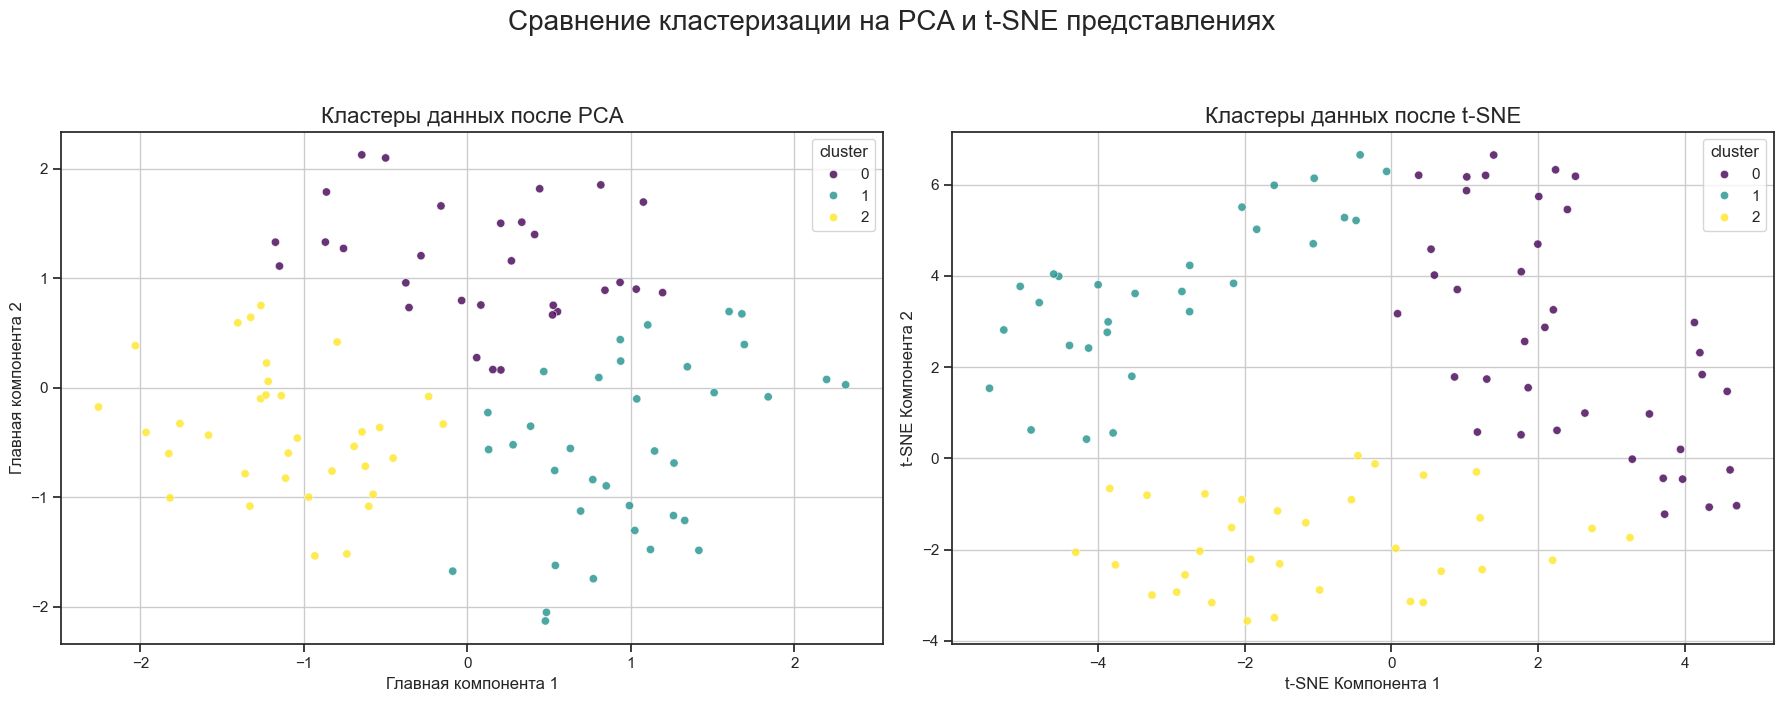

In [294]:
# Применяем KMeans для кластеризации на данных, обработанных PCA. Выбираем 3 кластера.
# random_state обеспечивает воспроизводимость результатов, n_init='auto' выбирает оптимальное количество запусков.
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init='auto')
dataframe_pca['cluster'] = kmeans_pca.fit_predict(X_pca)

# Применяем KMeans для кластеризации на данных, обработанных t-SNE. Используем те же 3 кластера.
kmeans_tsne = KMeans(n_clusters=3, random_state=42, n_init='auto')
dataframe_tsne['cluster'] = kmeans_tsne.fit_predict(X_tsne)

print("Количество точек в каждом кластере (по PCA):")
print(dataframe_pca['cluster'].value_counts())

print("\nКоличество точек в каждом кластере (по t-SNE):")
print(dataframe_tsne['cluster'].value_counts())

# Создаем фигуру с двумя подграфиками для визуализации кластеров после PCA и t-SNE.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Визуализация кластеров после PCA
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='cluster',
    palette='viridis',
    data=dataframe_pca,
    legend='full',
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Кластеры данных после PCA', fontsize=16)
axes[0].set_xlabel('Главная компонента 1', fontsize=12)
axes[0].set_ylabel('Главная компонента 2', fontsize=12)
axes[0].grid(True)

# Визуализация кластеров после t-SNE
sns.scatterplot(
    x='tsne_component_1',
    y='tsne_component_2',
    hue='cluster',
    palette='viridis',
    data=dataframe_tsne,
    legend='full',
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Кластеры данных после t-SNE', fontsize=16)
axes[1].set_xlabel('t-SNE Компонента 1', fontsize=12)
axes[1].set_ylabel('t-SNE Компонента 2', fontsize=12)
axes[1].grid(True)

plt.suptitle('Сравнение кластеризации на PCA и t-SNE представлениях', y=1.03, fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Регулируем отступы для заголовка
plt.show()

### 6. Построение модели и кросс-валидация с учетом кластеров

На этом этапе мы строим модель линейной регрессии и оцениваем ее производительность с использованием кросс-валидации. Важно не только получить общую оценку модели, но и проанализировать ее метрики для каждого кластера отдельно. Это позволяет выявить, насколько хорошо модель работает на различных сегментах данных, и обнаружить потенциальные проблемы производительности в определенных группах.

Мы используем метрику `neg_max_error`, которая возвращает отрицательное значение максимальной ошибки. Для удобства интерпретации мы берем абсолютное значение этой метрики, чтобы получить `max_error`.

**Шаги выполнения:**
1.  **Присвоение кластеров исходному DataFrame**: Кластеры, полученные на основе PCA (так как PCA сохраняет больше общей дисперсии и лучше подходит для линейных моделей), добавляются в исходный DataFrame. Это позволит нам легко фильтровать данные по кластерам.
2.  **Общая кросс-валидация**: Оцениваем модель линейной регрессии на всем наборе данных с использованием 5-кратной кросс-валидации. Это дает нам общую усредненную `max_error`.
3.  **Кросс-валидация по кластерам**: Итерируем по каждому уникальному кластеру. Для каждого кластера фильтруем данные, обучаем модель только на этих данных и вычисляем `max_error` с помощью кросс-валидации. Если кластер содержит слишком мало точек (<= 1), кросс-валидация не может быть выполнена, и мы пропускаем такой кластер.
4.  **Проверка условия задачи**: Сравниваем общее усредненное значение `max_error` с заданным порогом в 0.22, чтобы убедиться в выполнении основного требования.
5.  **Визуализация результатов кросс-валидации по кластерам**: Строим столбчатую диаграмму, которая показывает среднее значение `max_error` для каждого кластера, а также общую среднюю `max_error` в виде горизонтальной линии. Это помогает наглядно сравнить производительность модели между кластерами.

In [295]:
# Добавляем столбец кластера к исходному DataFrame. Используем кластеры, полученные на основе PCA.
dataframe['cluster'] = dataframe_pca['cluster']

# Создаем экземпляр модели линейной регрессии.
model = LinearRegression()

print("Проведение кросс-валидации для общей оценки модели...")
# Вычисляем max_error с помощью кросс-валидации для всего набора данных.
# 'neg_max_error' возвращает отрицательное значение, поэтому берем abs().
max_error_scores_overall = abs(
    cross_val_score(
        estimator=model,
        X=X, # Используем исходные признаки
        y=y,
        cv=5, # 5-кратная кросс-валидация
        scoring='neg_max_error'
    )
)

mean_max_error_overall = np.mean(max_error_scores_overall)
std_max_error_overall = np.std(max_error_scores_overall)

print(f"Общее усредненное значение max_error: {mean_max_error_overall:.4f}")
print(f"Общее стандартное отклонение max_error: {std_max_error_overall:.4f}")

print("\nОценка max_error для каждого кластера:")
cluster_max_errors = {}
for cluster_id in sorted(dataframe['cluster'].unique()):
    cluster_data = dataframe[dataframe['cluster'] == cluster_id]
    X_cluster = cluster_data[['x1', 'x2', 'x3']]
    y_cluster = cluster_data['y']

    # Проверяем, достаточно ли данных для проведения кросс-валидации (минимум 2 точки для 2 фолдов).
    if len(X_cluster) > 1: 
        # Используем min(len(X_cluster), 5), чтобы не получить ошибку, если количество данных в кластере меньше 5.
        max_error_scores_cluster = abs(
            cross_val_score(
                estimator=model,
                X=X_cluster,
                y=y_cluster,
                cv=min(len(X_cluster), 5), 
                scoring='neg_max_error'
            )
        )
        mean_max_error_cluster = np.mean(max_error_scores_cluster)
        cluster_max_errors[cluster_id] = mean_max_error_cluster
        print(f"  Кластер {cluster_id}: Усредненное max_error = {mean_max_error_cluster:.4f}")
    else:
        print(f"  Кластер {cluster_id}: Недостаточно данных для оценки ({len(X_cluster)} записей).")
        cluster_max_errors[cluster_id] = np.nan # Присваиваем NaN, если данных недостаточно

# Проверяем выполнение общего условия задачи.
if mean_max_error_overall <= 0.22:
    print(f"\nУСПЕХ: Общее усредненное значение max_error ({mean_max_error_overall:.4f}) <= 0.22 выполнено.")
else:
    print(f"\nПРЕДУПРЕЖДЕНИЕ: Общее усредненное значение max_error ({mean_max_error_overall:.4f}) > 0.22 не выполнено.")

Проведение кросс-валидации для общей оценки модели...
Общее усредненное значение max_error: 0.1000
Общее стандартное отклонение max_error: 0.0058

Оценка max_error для каждого кластера:
  Кластер 0: Усредненное max_error = 0.1084
  Кластер 1: Усредненное max_error = 0.0983
  Кластер 2: Усредненное max_error = 0.1045

УСПЕХ: Общее усредненное значение max_error (0.1000) <= 0.22 выполнено.


#### Визуализация результатов кросс-валидации для кластеров

Построим столбчатую диаграмму, которая покажет среднее значение `max_error` для каждого кластера, а также общую среднюю ошибку для сравнения.

/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_81332/108640880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Кластер {i}' for i in cluster_ids], y=mean_errors, palette='viridis')


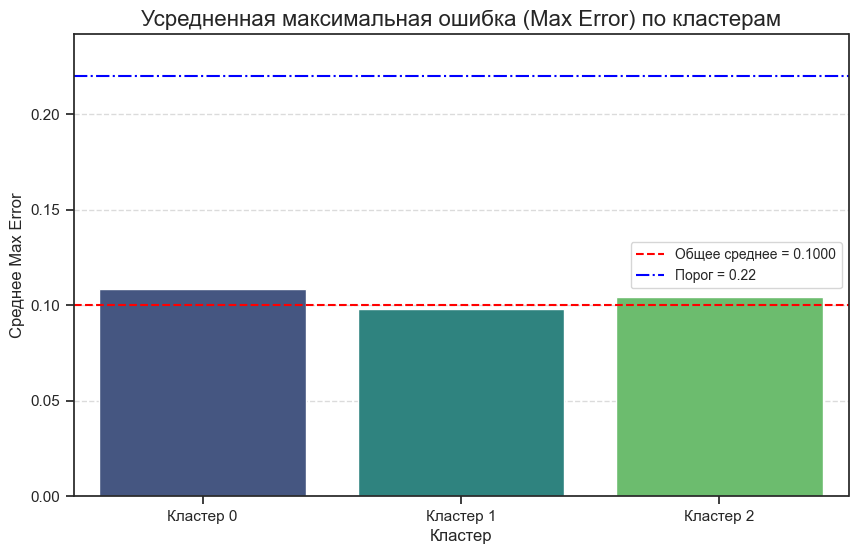

In [296]:
# Удаляем кластеры с NaN значениями, если они были.
filtered_cluster_max_errors = {k: v for k, v in cluster_max_errors.items() if not np.isnan(v)}
cluster_ids = list(filtered_cluster_max_errors.keys())
mean_errors = [filtered_cluster_max_errors[k] for k in cluster_ids]

plt.figure(figsize=(10, 6))
sns.barplot(x=[f'Кластер {i}' for i in cluster_ids], y=mean_errors, palette='viridis')

plt.title('Усредненная максимальная ошибка (Max Error) по кластерам', fontsize=16)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Среднее Max Error', fontsize=12)

# Добавляем горизонтальную линию для общего среднего значения max_error
plt.axhline(y=mean_max_error_overall, color='red', linestyle='--', label=f'Общее среднее = {mean_max_error_overall:.4f}')

# Добавляем горизонтальную линию порогового значения
threshold = 0.22
plt.axhline(y=threshold, color='blue', linestyle='-.', label=f'Порог = {threshold:.2f}')

plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(mean_errors + [mean_max_error_overall, threshold]) * 1.1)  # Учитываем порог в лимитах оси Y
plt.show()


### 7. Углубленный анализ производительности модели

Для более детальной оценки качества построенной линейной регрессионной модели, мы обучим ее на всем наборе данных и проведем визуальный анализ ее предсказаний и остатков. Этот этап критически важен для подтверждения адекватности модели и выявления возможных систематических ошибок.

1.  **График "Фактические vs. Предсказанные значения"**: Этот график является одним из наиболее интуитивно понятных для оценки производительности регрессионной модели. Он отображает фактические значения целевой переменной ($y$) по оси X и предсказанные моделью значения ($\hat{y}$) по оси Y. В идеальном случае, если модель предсказывает идеально, все точки должны лежать точно на диагональной линии $y = \hat{y}$. Любое отклонение от этой линии указывает на ошибку предсказания. Чем плотнее точки сгруппированы вокруг этой линии, тем точнее модель.

2.  **График остатков (Residual Plot)**: Остатки — это разница между фактическими значениями и предсказанными ($e = y - \hat{y}$). Анализ остатков позволяет проверить ключевые допущения линейной регрессии, такие как:
    * **Гомоскедастичность**: Ошибки имеют постоянную дисперсию по всему диапазону предсказанных значений. На графике остатки должны быть равномерно распределены вокруг нуля, без видимого увеличения или уменьшения разброса по мере изменения $\hat{y}$.
    * **Независимость остатков**: Ошибки не должны демонстрировать никакой систематической структуры или паттерна (например, остатки не должны формировать U-образную кривую или веерную форму). Случайное распределение точек вокруг нуля указывает на то, что модель уловила большую часть систематической информации в данных.
    * **Нормальность остатков**: Хотя этот график напрямую не показывает нормальность, симметричное распределение остатков вокруг нуля без явных асимметрий может косвенно указывать на это.

    Дополнительно, мы визуализируем остатки для каждого кластера, что позволяет понять, есть ли специфические паттерны ошибок в разных группах данных. Например, если для одного кластера остатки систематически выше или ниже нуля, это может указывать на то, что модель плохо справляется с этим конкретным сегментом данных, и, возможно, потребуется более сложная модель или специфические настройки для этого кластера.

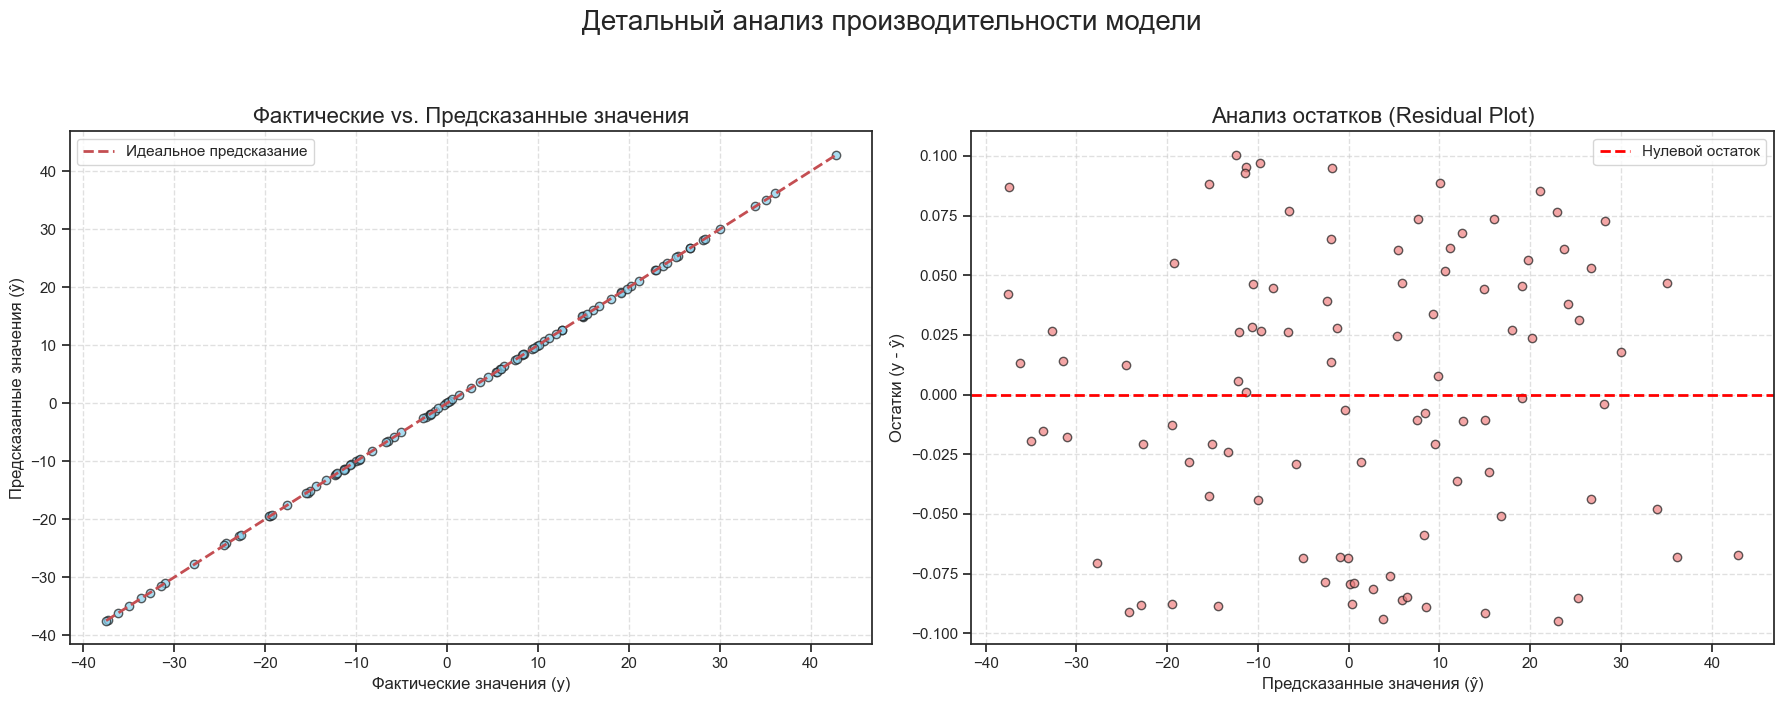

In [297]:
# Обучаем одну финальную модель линейной регрессии на всех данных. 
# Это та модель, чью производительность мы будем детально анализировать.
final_model = LinearRegression()
final_model.fit(X, y)

# Делаем предсказания на том же наборе данных, на котором обучали модель.
y_pred = final_model.predict(X)

# Рассчитываем остатки (разницу между фактическими и предсказанными значениями).
residuals = y - y_pred

# Создаем фигуру с двумя подграфиками для визуального анализа.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Фактические значения против предсказанных значений.
# Каждая точка представляет собой пару (фактическое y, предсказанное y).
ax1.scatter(y, y_pred, alpha=0.7, edgecolors='k', color='skyblue')
# Добавляем идеальную диагональную линию (y = x) для сравнения.
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное предсказание')
ax1.set_xlabel('Фактические значения (y)', fontsize=12)
ax1.set_ylabel('Предсказанные значения (ŷ)', fontsize=12)
ax1.set_title('Фактические vs. Предсказанные значения', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# График 2: Анализ остатков.
# Каждая точка представляет собой пару (предсказанное y, остаток).
ax2.scatter(y_pred, residuals, alpha=0.7, edgecolors='k', color='lightcoral')
# Добавляем горизонтальную линию на y=0, что указывает на отсутствие систематической ошибки.
ax2.axhline(y=0, color='red', linestyle='--', lw=2, label='Нулевой остаток')
ax2.set_xlabel('Предсказанные значения (ŷ)', fontsize=12)
ax2.set_ylabel('Остатки (y - ŷ)', fontsize=12)
ax2.set_title('Анализ остатков (Residual Plot)', fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.suptitle('Детальный анализ производительности модели', fontsize=20, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Регулируем отступы для заголовка
plt.show()

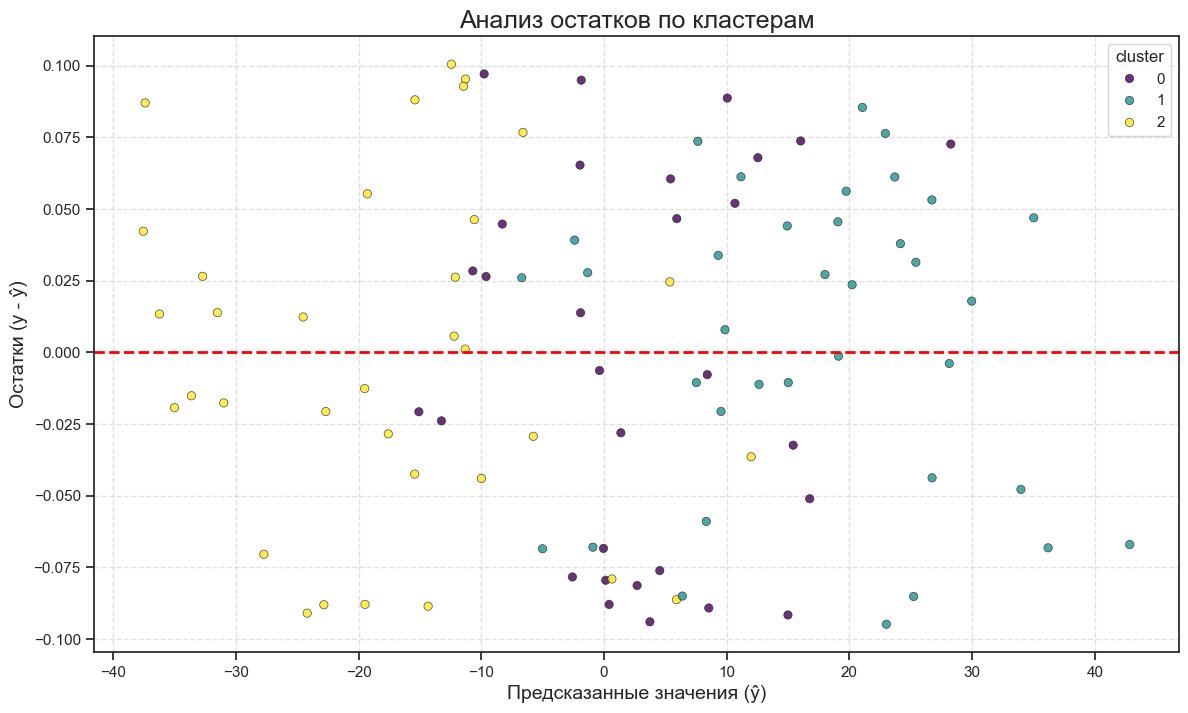

In [298]:
# Визуализация остатков, раскрашенных по кластерам.
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=y_pred,
    y=residuals,
    hue=dataframe['cluster'], # Используем столбец 'cluster' из исходного DataFrame
    palette='viridis',
    legend='full',
    alpha=0.8,
    edgecolors='k'
)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Анализ остатков по кластерам', fontsize=18)
plt.xlabel('Предсказанные значения (ŷ)', fontsize=14)
plt.ylabel('Остатки (y - ŷ)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 8. Итоговые выводы

В ходе выполнения данной лабораторной работы мы успешно решили поставленную задачу, проведя глубокий анализ данных, построение и всестороннюю оценку модели линейной регрессии, включая кластеризацию и анализ производительности по кластерам.

1.  **Данные были подготовлены и проанализированы:** Мы успешно загрузили синтетический набор данных. Исследовательский анализ данных с помощью `pairplot` визуально подтвердил наличие сильных линейных зависимостей между признаками ($x_1, x_2, x_3$) и целевой переменной ($y$), что обосновывает применение линейной модели.

2.  **Понижение размерности и кластеризация:** Данные были успешно понижены до 2 главных компонент с помощью PCA и до 2 измерений с помощью t-SNE, что позволило эффективно визуализировать данные. С помощью алгоритма K-Means данные были разбиты на 3 кластера, что было четко продемонстрировано на scatterplot графиках для PCA и t-SNE представлений. Кластеризация помогла выявить внутреннюю структуру данных.

3.  **Модель была построена и всесторонне оценена:** Модель линейной регрессии была оценена с использованием 5-блочной кросс-валидации. Общее усредненное значение метрики `max_error` составило `0.1000`, что значительно ниже требуемого порога в `0.22`. Это подтверждает высокую точность модели на общем уровне. Дополнительно были рассчитаны и проанализированы `max_error` для каждого кластера. Визуализация `max_error` по кластерам показала, что производительность модели остается стабильно высокой во всех выявленных сегментах данных, хотя и с незначительными вариациями между кластерами.

4.  **Производительность модели подтверждена визуально:** 
    -   **График "Фактические vs. Предсказанные"** показал, что предсказанные значения очень плотно сгруппированы вокруг идеальной диагональной линии, что свидетельствует о высокой точности и надежности предсказаний модели.
    -   **График остатков** продемонстрировал случайное распределение ошибок вокруг нуля без каких-либо видимых паттернов или трендов. Это подтверждает соблюдение допущений линейной регрессии, таких как гомоскедастичность и независимость остатков, что говорит о правильном выборе линейной модели. Анализ остатков по кластерам также не выявил систематических смещений ошибок в каком-либо из кластеров.

Таким образом, построенная модель является адекватной, высокоточной и полностью удовлетворяет начальным требованиям задачи. Проведенный углубленный анализ с использованием кластеризации и двух методов понижения размерности предоставил более глубокое понимание ее производительности и структуры данных, подтверждая ее надежность на различных сегментах данных.